In [32]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [33]:
pd.set_option('display.max_columns', None)

In [34]:
df = pd.read_csv('data_gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [35]:
df.shape

(3658, 26)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\444587821.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

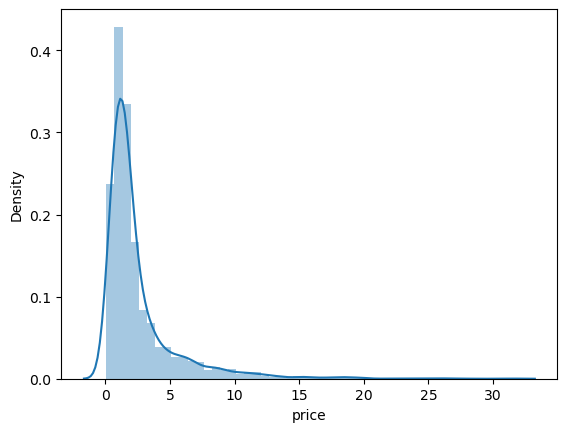

In [36]:
sns.distplot(df['price'])

<Axes: ylabel='price'>

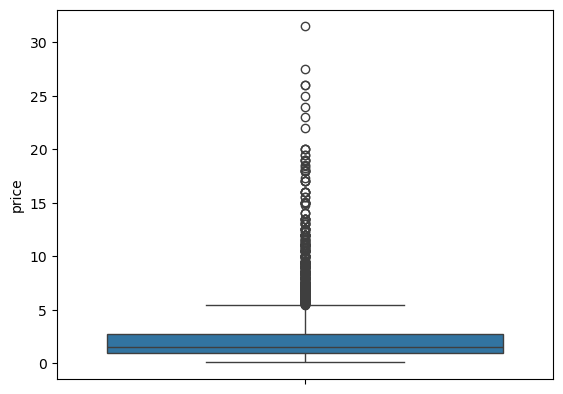

In [37]:
sns.boxplot(df['price'])

In [38]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [39]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [40]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [41]:
outliers_sqft['price_per_sqft'].describe()

count      354.000000
mean     28982.251412
std      12041.176363
min       2733.000000
25%      25297.000000
50%      29615.000000
75%      35448.500000
max      71915.000000
Name: price_per_sqft, dtype: float64

In [42]:
df.update(outliers_sqft)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

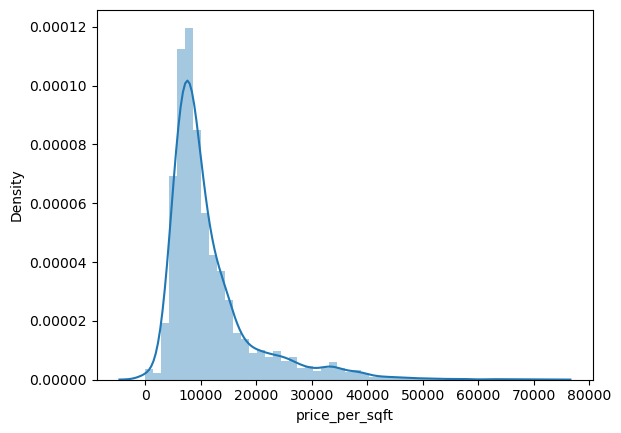

In [43]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

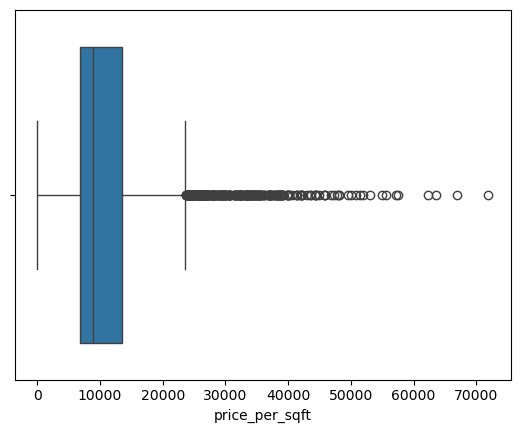

In [44]:
sns.boxplot(x=df['price_per_sqft'])

In [45]:
df[df['price_per_sqft']>50000]

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
102,4 Bedroom House for sale in Sector 54 Gurgaon,house,emaar the palm springs,sector 54,14.00,62254.0,2248.84,Plot area 250(209.03 sq.m.),4,5,3,"The Palm Springs Villa, Sector 54 Gurgaon, Gur...",2.0,North,Old Property,Bathrooms\n Imported marble flooring in master...,NaN,250.0,NaN,1,1,0,0,0,0,160
193,6 Bedroom House for sale in DLF Phase 1,house,dlf city plots,sector 26,26.00,57260.0,4540.72,Plot area 505(422.24 sq.m.),6,7,3,"0000, DLF Phase 1, Gurgaon, Haryana",2.0,North-East,New Property,505 sq.Y 6 bhk luxury villa \nIn dlf phase 1\n...,NaN,505.0,NaN,1,1,0,1,1,0,138
241,16 Bedroom House for sale in DLF Phase 4,house,nul,sector 28,12.50,51403.0,2431.76,Plot area 270(225.75 sq.m.),16,17,3,"DLF Phase 4, Gurgaon, Haryana",4.0,South,Relatively New,270 sq yard 4bhk par floor brand new building ...,NaN,270.0,NaN,1,1,0,1,1,2,137
625,16 Bedroom House for sale in DLF Phase 1,house,NaN,sector 26,26.00,71915.0,3615.36,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3,"Dlf Phase 1, DLF Phase 1, Gurgaon, Haryana",4.0,North-West,New Property,"Dlf phase 1 very prime location , this buildin...",NaN,400.0,350.0,1,1,1,1,0,0,72
1248,16 Bedroom House for sale in DLF Phase 2,house,NaN,sector 25,16.00,50750.0,3152.68,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3,"Dlf Phase 2, DLF Phase 2, Gurgaon, Haryana",4.0,West,New Property,"Dlf phase 2 very prime location , this buildin...",NaN,325.0,300.0,1,1,1,1,0,0,72
1429,3 BHK Flat in Sector 70 Gurgaon,flat,unitech vistas,sector 70,9.00,57508.0,1565.00,Built Up area: 1565 (145.39 sq.m.),3,3,0,"Sector 70, Sector 70 Gurgaon, Gurgaon, Haryana",7.0,DK,Undefined,Best in class property available at sector 70 ...,NaN,1565.0,NaN,0,0,0,0,0,1,0
1835,3 Bedroom House for sale in Sohna Road,house,cloudnine cottages,sohna road road,5.50,54963.0,1000.68,Plot area 1000(92.9 sq.m.),3,3,0,"Sohna Road, Gurgaon, Haryana",1.0,DK,Moderately Old,I am looking for buyer to purchase house/villa...,NaN,1000.0,NaN,0,0,0,0,0,1,0
2091,5 Bedroom House for sale in Sector 54 Gurgaon,house,emaar the palm springs,sector 54,24.00,66981.0,3583.08,Plot area 400(37.16 sq.m.),5,5,2,"Sector 54 Gurgaon, Gurgaon, Haryana",1.0,North-East,Old Property,Emaar palm spring sector-54 (Villa) 400 gaj ba...,NaN,400.0,NaN,1,1,0,1,0,0,122
2214,4 Bedroom House for sale in Sector 66 Gurgaon,house,emaar mgf marbella,sector 66,18.00,55577.0,3238.76,Plot area 360(301.01 sq.m.),4,4,3,"B10, Sector 66 Gurgaon, Gurgaon, Haryana",3.0,East,Moderately Old,Check out this 4 bhk house for sale in sector ...,NaN,360.0,NaN,1,1,0,1,0,2,75
2217,12 Bedroom House for sale in Malibu Town,house,malibu towne,sector 47,8.50,53018.0,1603.24,Built Up area: 1600 (148.64 sq.m.),12,12,3,"Redwood 14, Malibu Town, Gurgaon, Haryana",4.0,North,New Property,It's a wholly distinctive home with three open...,NaN,1600.0,NaN,0,0,0,0,0,0,99


In [46]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

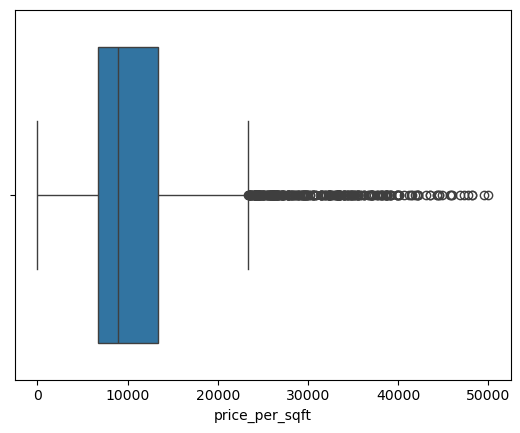

In [47]:
sns.boxplot(x=df['price_per_sqft'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

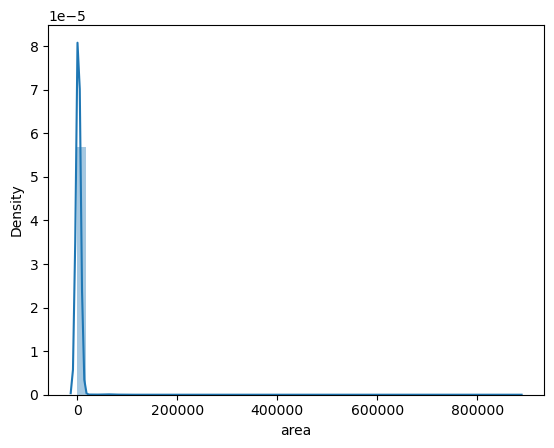

In [48]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

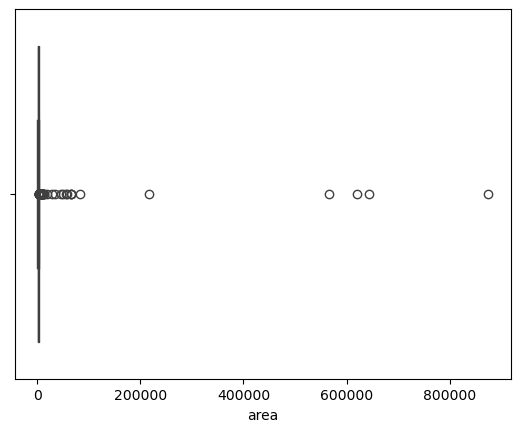

In [49]:
sns.boxplot(x=df['area'])

In [50]:
df['area'].describe()

count      3646.000000
mean       2894.216072
std       23144.813501
min         139.880000
25%        1261.000000
50%        1749.500000
75%        2340.250000
max      875000.000000
Name: area, dtype: float64

In [51]:
df[df['area'] > 100000]

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
156,2 BHK Flat in Sector 95A Gurgaon,flat,signature the roselia,sector 95,0.45,7.0,642857.00,Carpet area: 569243 (52884.41 sq.m.),2,2,2,"Sector 95A Gurgaon, Gurgaon, Haryana",2.0,South-West,New Property,"Highly ventilated and trusted builder, spaciou...",NaN,NaN,569243.0,0,0,0,0,0,1,76
1331,2 BHK Flat in Sohna,flat,hcbs sports ville,sohna road,0.35,4.0,875000.00,Built Up area: 737147 (68483.2 sq.m.),2,2,2,"Sohna, Gurgaon, Haryana",8.0,DK,Relatively New,"View is awesome, towards the aravalli and fres...",NaN,737147.0,NaN,0,0,0,0,0,2,44
1833,6 Bedroom House for sale in Sector 50 Gurgaon,house,NaN,sector 50,5.00,232.0,215888.64,Plot area 2(1011.71 sq.m.),6,5,3,"Sector 50 Gurgaon, Gurgaon, Haryana",2.0,DK,New Property,This 6 bhk house for sale in sector 50 gurgaon...,NaN,2.0,NaN,1,1,0,1,1,0,0
2745,2 BHK Flat in Sector 107 Gurgaon,flat,signature global solera 2,sector 107,0.51,9.0,566667.00,Carpet area: 514396 (47788.95 sq.m.),2,2,1,"A5 301, Sector 107 Gurgaon, Gurgaon, Haryana",3.0,North,New Property,It is near metro it is very beautiful,NaN,NaN,514396.0,0,0,0,0,0,1,44
3654,2 BHK Flat in Sector 95 Gurgaon,flat,ramsons kshitij,sector 95,0.31,5.0,620000.00,Carpet area: 607936 (56479.1 sq.m.),2,2,1,"Sector 95 Gurgaon, Gurgaon, Haryana",1.0,North-East,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,607936.0,1,0,0,0,1,1,65


In [52]:
df = df[df['area'] < 100000]

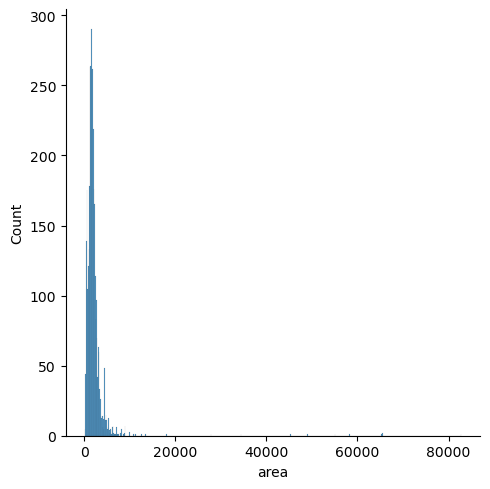

In [53]:
sns.displot(df['area'])

<Axes: xlabel='area'>

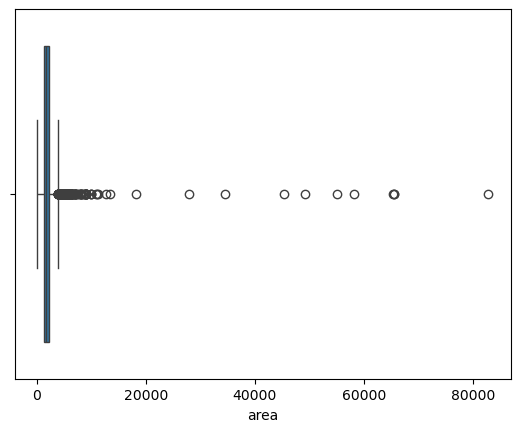

In [54]:
sns.boxplot(x = df['area'])

In [55]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2381,10 Bedroom House for sale in Prem Nagar,house,ganpati heights apartment,sector 13,1.25,151.0,82765.92,Plot area 115(7692.86 sq.m.),10,6,2,"Prem Nagar, Gurgaon, Haryana",3.0,South-East,Old Property,Next to gurgaon bus depot. 10 mins walking dis...,NaN,115.0,NaN,0,0,0,0,1,1,7
95,3 BHK Flat in Sector 95 Gurgaon,flat,rof ananda,sector 95,0.38,58.0,65517.00,Carpet area: 64412 (5984.07 sq.m.),3,2,1,"Sector 95 Gurgaon, Gurgaon, Haryana",12.0,North,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,64412.00,0,0,0,0,0,1,51
2981,2 BHK Flat in Sector 95 Gurgaon,flat,rof ananda,sector 95,0.38,58.0,65517.00,Carpet area: 64529 (5994.94 sq.m.),2,2,2,"E1002, Sector 95 Gurgaon, Gurgaon, Haryana",10.0,East,New Property,Its rera approved and best built quality made ...,NaN,NaN,64529.00,1,0,0,0,0,1,15
2774,10 Bedroom House for sale in DLF Phase 4,house,dlf city plot phase 4,sector 28,13.00,1992.0,65227.12,Carpet area: 7250 (6061.92 sq.m.),10,10,3,"Dlf City Phase 4, Sector 28, DLF Phase 4, Gurg...",1.0,DK,Undefined,Best in class property available at dlf city p...,NaN,NaN,7250.00,0,0,0,0,0,1,0
577,2 BHK Flat in Sector 86 Gurgaon,flat,pyramid elite,sector 86,0.46,79.0,58228.00,Carpet area: 58141 (5401.48 sq.m.),2,2,1,"Sector 86 Gurgaon, Gurgaon, Haryana",0.0,DK,Under Construction,Near to dwarka expressway\nNear to airport,NaN,NaN,58141.00,0,0,0,0,0,1,15
1956,2 BHK Flat in Sector 95 Gurgaon,flat,rof ananda,sector 95,0.33,60.0,55000.00,Carpet area: 54917 (5101.96 sq.m.),2,2,1,"Sector 95 Gurgaon, Gurgaon, Haryana",13.0,South-West,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,54917.00,0,0,0,0,0,1,37
2082,1 BHK Flat in Sohna,flat,signature the serenas,sohna road,0.28,57.0,49123.00,Carpet area: 48811 (4534.69 sq.m.),1,1,2,"0001, Sohna, Gurgaon, Haryana",1.0,North-West,Relatively New,This project is signature builder. On road soc...,NaN,NaN,48811.00,1,0,0,0,0,1,37
1213,2 BHK Flat in Sector 95 Gurgaon,flat,ramsons kshitij,sector 95,0.24,53.0,45283.00,Carpet area: 45966 (4270.38 sq.m.),2,2,1,"Sector 95 Gurgaon, Gurgaon, Haryana",10.0,North-West,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,45966.00,0,0,0,0,1,1,33
558,1 BHK Flat in Sector 95 Gurgaon,flat,rof ananda,sector 95,0.21,61.0,34426.00,Carpet area: 34401 (3195.96 sq.m.),1,1,1,"Sector 95 Gurgaon, Gurgaon, Haryana",13.0,North,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,34401.00,0,0,0,0,0,1,68
17,9 Bedroom House for sale in Sector 57 Gurgaon,house,NaN,sector 57,6.25,2778.0,27889.92,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3,"26.........., Sector 57 Gurgaon, Gurgaon, Haryana",3.0,North-East,New Property,Are you planning to buy your dream home? You c...,NaN,2660.0,2500.00,0,1,0,0,0,0,61


In [60]:
df.drop(index=[2381,   95, 2981, 2774,  577, 1956, 2082, 1213,  558,   17, 2087, 2263,
         38, 2982, 3196, 3154 ], inplace=True)

In [61]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score


C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

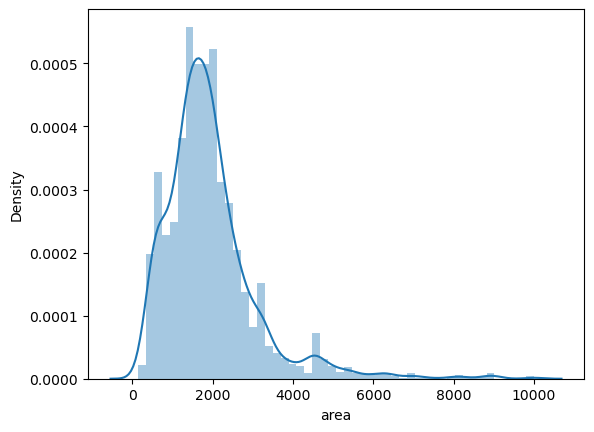

In [62]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

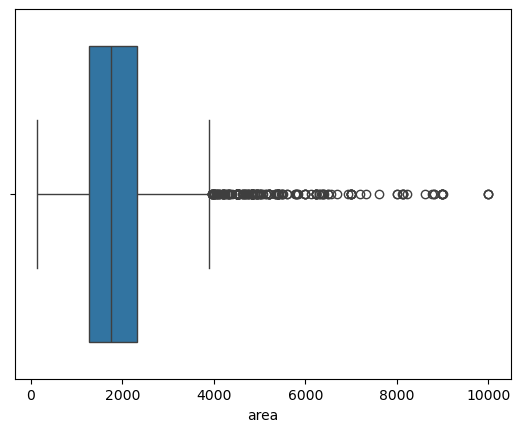

In [63]:
sns.boxplot(x=df['area'])

In [64]:
df['area'].describe()

count     3625.000000
mean      1932.572590
std       1173.115661
min        139.880000
25%       1260.000000
50%       1744.000000
75%       2320.000000
max      10000.000000
Name: area, dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

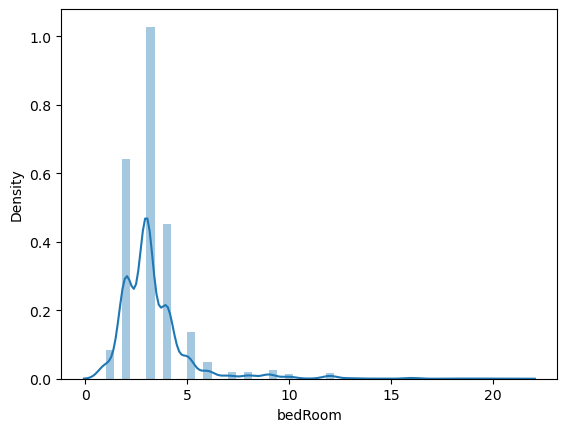

In [65]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

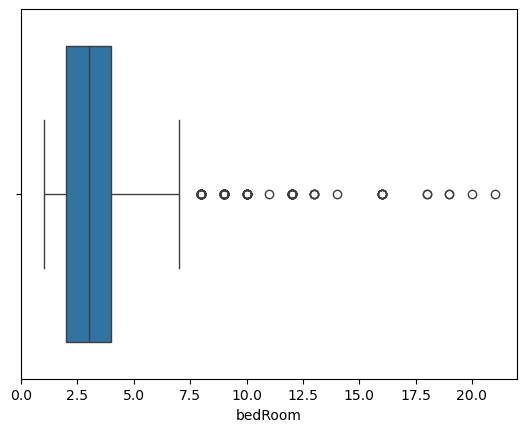

In [66]:
sns.boxplot(x=df['bedRoom'])

In [67]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
69,21 Bedroom House for sale in Sector 54 Gurgaon,house,NaN,sector 54,5.00,43026.0,1162.08,Plot area 129(107.86 sq.m.),21,21,3,"Sector 54 Gurgaon, Gurgaon, Haryana",5.0,North,Relatively New,"129 sq yd plot size. 5 floors built up , fully...",NaN,129.0,NaN,0,1,0,0,0,2,49
3527,20 Bedroom House for sale in Sushant Lok Phase 1,house,NaN,sector 43,4.50,39086.0,1151.32,Plot area 128(107.02 sq.m.),20,20,3,"Sushant Lok Phase 1, Gurgaon, Haryana",4.0,East,Relatively New,Best for investment purpose. 3l rupees monthly...,NaN,128.0,NaN,0,1,0,0,0,2,22
509,19 Bedroom House for sale in Sector 17A Gurgaon,house,NaN,sector 17a,3.87,5160.0,1624.76,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3,"690, Sector 17A Gurgaon, Gurgaon, Haryana",5.0,North-West,Relatively New,The building is equipped with modern fittings....,NaN,7500.0,NaN,1,0,1,0,0,1,68
3492,19 Bedroom House for sale in Sector 17A Gurgaon,house,NaN,sector 17a,3.93,24214.0,1624.76,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,"690, Sector 17A Gurgaon, Gurgaon, Haryana",4.0,North-West,Relatively New,"8% return yearly, very safe sector, supportive...",NaN,1622.0,NaN,1,1,1,1,0,1,74
1861,18 Bedroom House for sale in Suncity,house,NaN,sector 54,5.50,38146.0,1441.84,Plot area 160(133.78 sq.m.),18,18,3,"11111, Suncity, Gurgaon, Haryana",4.0,South-West,Relatively New,18 bed room newly built up in 160 yds plot is ...,NaN,160.0,NaN,0,1,0,0,0,2,70
1192,18 Bedroom House for sale in Sector 55 Gurgaon,house,private house,sector 55,7.05,46800.0,1506.40,Plot area 167(139.63 sq.m.),18,18,3,"A1/29, Sector 55 Gurgaon, Gurgaon, Haryana",4.0,North-East,Relatively New,18furnished rooms with all interior and goods ...,NaN,167.0,NaN,0,0,0,0,1,2,57
1523,16 Bedroom House for sale in Sector 40 Gurgaon,house,NaN,sector 40,12.00,38994.0,3077.36,Plot area 342(285.96 sq.m.),16,16,3,"Sector 40 Gurgaon, Gurgaon, Haryana",4.0,DK,New Property,Ready to move in simplex kothi available for s...,NaN,342.0,NaN,1,1,1,1,0,0,0
3629,16 Bedroom House for sale in Shivaji Nagar,house,NaN,sector 11,4.50,25043.0,1796.92,Plot area 200(167.23 sq.m.),16,16,3,"1111, Shivaji Nagar, Gurgaon, Haryana",4.0,South,Relatively New,Shivaji nagar is one of gurgaon's most sought ...,NaN,200.0,NaN,0,0,0,0,0,0,20
3082,16 Bedroom House for sale in Sector 56 Gurgaon,house,NaN,sector 56,12.39,45876.0,2700.76,Plot area 300(250.84 sq.m.),16,18,3,"353, Sector 56 Gurgaon, Gurgaon, Haryana",4.0,North-East,New Property,Check out this 16 bhk house for sale in sector...,NaN,300.0,NaN,0,1,0,1,0,0,49
2836,16 Bedroom House for sale in DLF Phase 1,house,dlf city plots,sector 26,20.00,44256.0,4519.20,Plot area 502(419.74 sq.m.),16,20,3,"Full Building Best Deal, DLF Phase 1, Gurgaon,...",4.0,North-East,New Property,North east facing\nNear to paschim marg\nPosh ...,NaN,502.0,NaN,1,1,1,1,0,0,153


In [68]:
df = df[df['bedRoom'] <= 10]

In [69]:
df.shape

(3580, 26)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

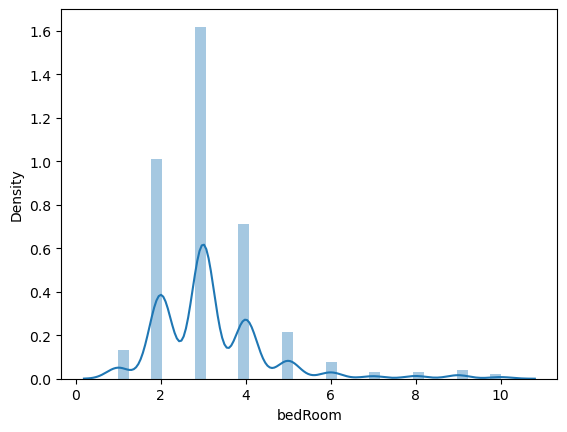

In [70]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

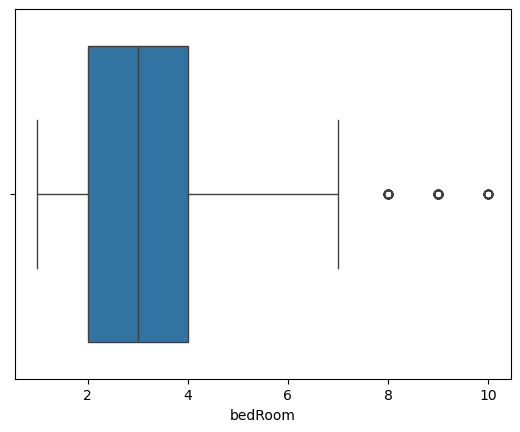

In [71]:
sns.boxplot(x=df['bedRoom'])

In [72]:
df['bedRoom'].describe()

count    3580.000000
mean        3.198045
std         1.382300
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

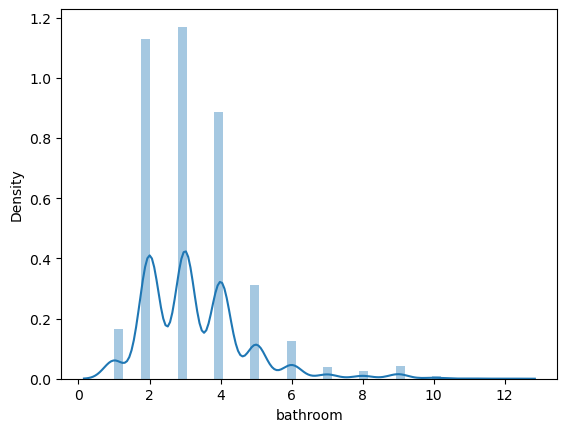

In [73]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

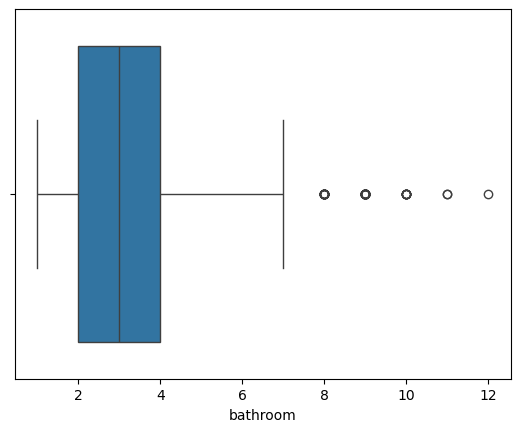

In [74]:
sns.boxplot(x=df['bathroom'])

In [75]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
819,9 Bedroom House for sale in Sector 60 Gurgaon,house,adani brahma samsara,sector 60,18.02,28194.0,6391.44,Built Up area: 6390 (593.65 sq.m.),9,12,3,"Sector 60 Gurgaon, Gurgaon, Haryana",3.0,North-East,Relatively New,An impeccable opportunity is here for those wh...,NaN,6390.0,NaN,0,1,0,0,0,0,146
472,8 Bedroom House for sale in DLF Phase 3,house,NaN,sector 24,11.00,28879.0,3809.04,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3,"Dlf -3, DLF Phase 3, Gurgaon, Haryana",3.0,East,Old Property,Independent house available for sale.,NaN,5000.0,NaN,1,1,0,1,1,0,39
813,10 Bedroom House for sale in Sector 39 Gurgaon,house,NaN,sector 39,7.00,10000.0,355.08,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3,"167, Sector 39 Gurgaon, Gurgaon, Haryana",4.0,South-East,Relatively New,"Luxury house 10 bhk, floor wise, basement plus...",NaN,7000.0,NaN,0,0,0,1,0,0,38


C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

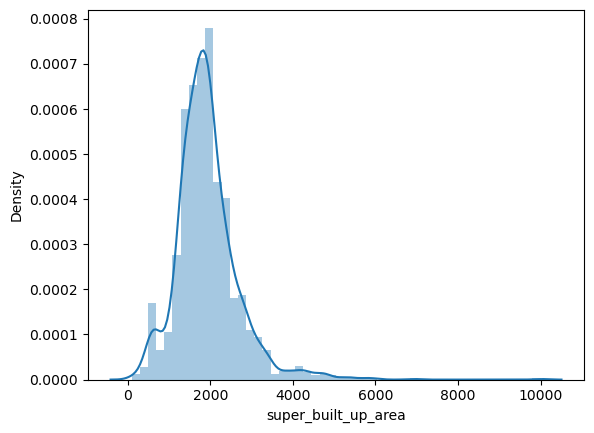

In [76]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

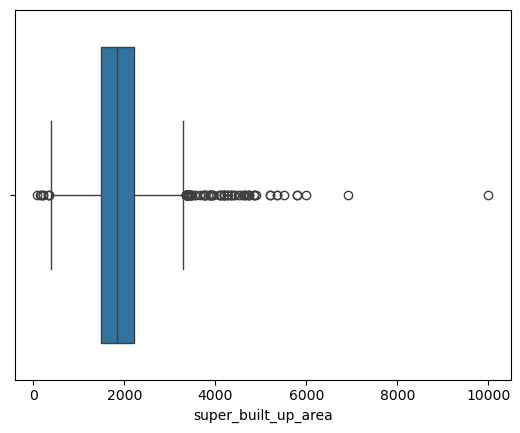

In [77]:
sns.boxplot(x=df['super_built_up_area'])

In [78]:
df['super_built_up_area'].describe()

count     1874.000000
mean      1924.984285
std        764.297382
min         89.000000
25%       1479.250000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [79]:
df[df['super_built_up_area'] > 6000]

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2141,5 BHK Flat in Gwal Pahari,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3,"Gwal Pahari, Gurgaon, Haryana",23.0,North-East,Relatively New,"It is a beautiful penthouse with 10,000/- Sqft...",10000.0,NaN,NaN,0,1,0,1,1,1,49
3657,4 BHK Flat in Sector 81 Gurgaon,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3,"1908, Sector 81 Gurgaon, Gurgaon, Haryana",19.0,North,Relatively New,Semi furnished 4bhk 6926sqft penthouse with pe...,6926.0,NaN,NaN,0,1,0,0,0,0,140


C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

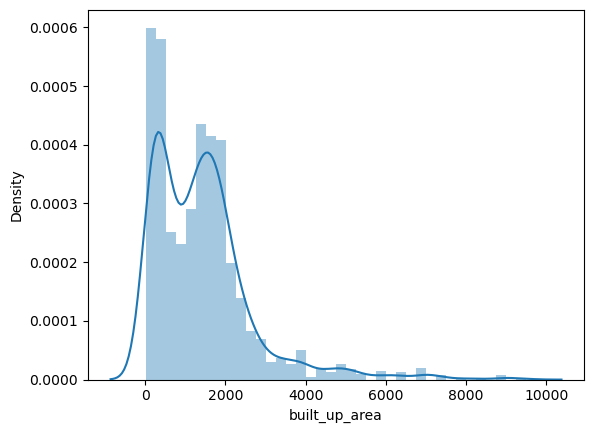

In [80]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

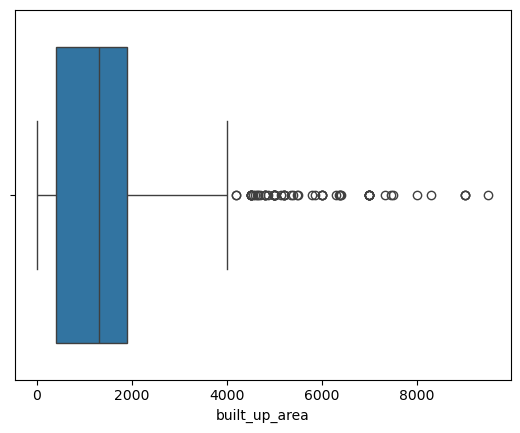

In [81]:
sns.boxplot(x=df['built_up_area'])

In [84]:
df[df['built_up_area'] > 8000]

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
202,9 Bedroom House for sale in Sector 12 Gurgaon,house,anamika enclave,sector 12,6.0,14492.0,4142.60,Plot area 4140(384.62 sq.m.)Built Up area: 900...,9,9,3,"9/77/27, Sector 12 Gurgaon, Gurgaon, Haryana",3.0,North-West,Old Property,"Independent basement entry ,submersible water ...",NaN,9000.0,NaN,0,0,0,0,0,1,9
689,7 Bedroom House for sale in Sushant Lok Phase 1,house,ansal sushant lok plots,sector 43,11.5,17692.0,3766.00,Plot area 3762(349.5 sq.m.)Built Up area: 9000...,7,8,3,"Built Up House, Park And North Facing, Sushant...",3.0,DK,Old Property,"7bhk independent house on sale, c sushant lok-...",NaN,9000.0,6500.0,0,1,1,1,0,0,31
1791,5 Bedroom House for sale in Sector 73 Gurgaon,house,dlf alameda,sector 73,17.0,35109.0,4842.00,Plot area 4842(449.84 sq.m.)Built Up area: 900...,5,8,3,"Alameda, Sector 73 Gurgaon, Gurgaon, Haryana",3.0,North-West,Relatively New,It is a tastefully made villa with best of des...,NaN,9000.0,NaN,1,1,1,1,0,2,87
2334,5 Bedroom House for sale in DLF Phase 2,house,NaN,sector 25,10.0,37027.0,2700.76,Plot area 2700(250.84 sq.m.)Built Up area: 950...,5,5,3,"M Block Corner, DLF Phase 2, Gurgaon, Haryana",3.0,East,Moderately Old,This is corner unit near to highway five bedro...,NaN,9500.0,9000.0,0,1,0,1,0,2,29
3270,10 Bedroom House for sale in Sector 56 Gurgaon,house,NaN,sector 56,8.0,9654.0,365.84,Plot area 362(33.63 sq.m.)Built Up area: 8286 ...,10,10,3,"Huda Plots, Sector 56 Gurgaon, Gurgaon, Haryana",4.0,DK,Relatively New,This newly renovated and furnished home is fab...,NaN,8286.0,NaN,1,1,0,1,0,2,107


C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

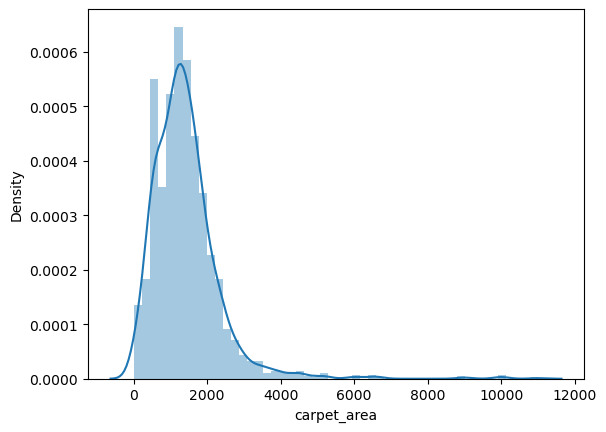

In [85]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

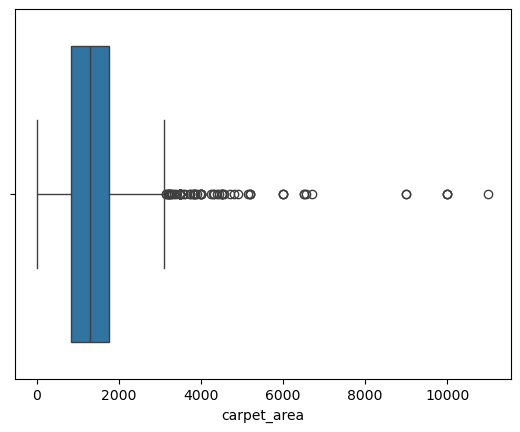

In [86]:
sns.boxplot(x=df['carpet_area'])

In [87]:
df[df['carpet_area'] > 10000]

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1940,6 Bedroom House for sale in DLF Phase 1,house,NaN,sector 26,18.4,1859.0,4519.2,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3,"111, DLF Phase 1, Gurgaon, Haryana",4.0,South,Relatively New,Dlf city phase 1 a block duplex kothi sale in ...,NaN,NaN,11000.0,0,1,1,1,0,0,60


C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

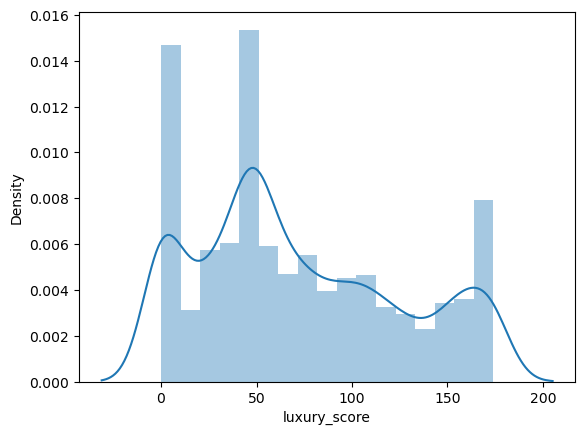

In [88]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

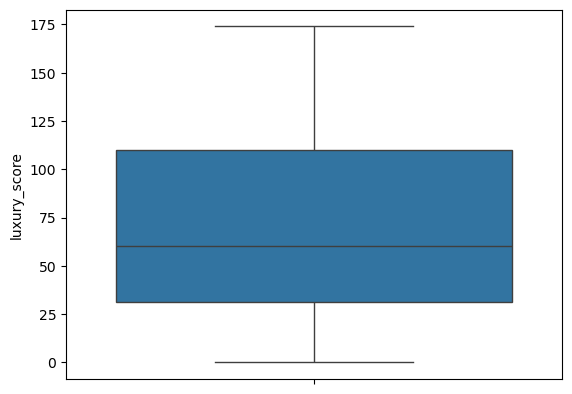

In [89]:
sns.boxplot(df['luxury_score'])

In [93]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_13904\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

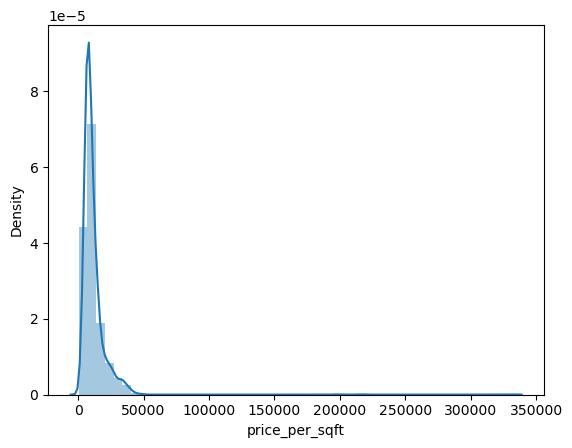

In [94]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='area', ylabel='Count'>

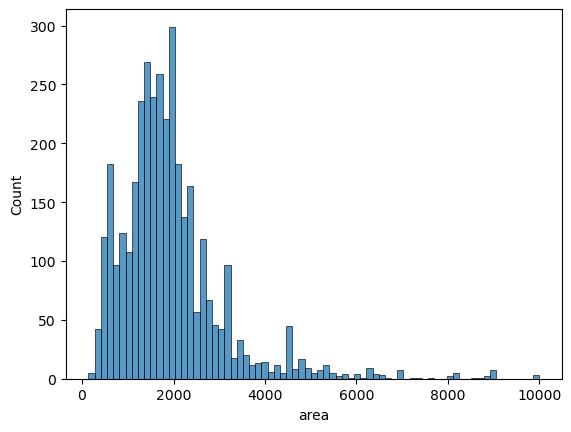

In [95]:
sns.histplot(df['area'])

<Axes: ylabel='price_per_sqft'>

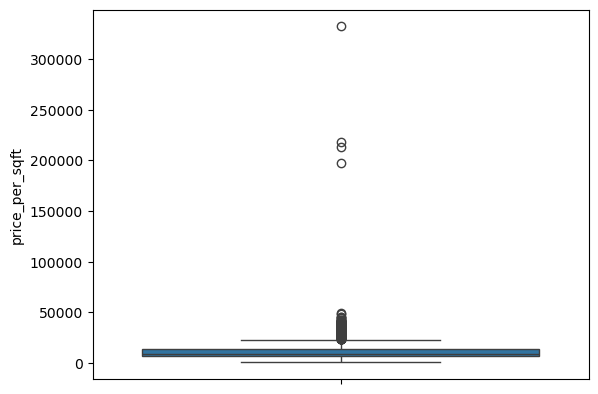

In [96]:
sns.boxplot(df['price_per_sqft'])

In [97]:
df[df['price_per_sqft'] > 42000]

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
238,6 Bedroom House for sale in DLF Phase 1,house,NaN,sector 26,19.00,42244.0,4497.68,Plot area 500(418.06 sq.m.),6,8,3,"A18, DLF Phase 1, Gurgaon, Haryana",3.0,East,Moderately Old,"Dlf phase 1, gurgaon, haryana\nBeautifully wel...",NaN,500.0,NaN,1,1,1,1,0,0,103
404,3 Bedroom House for sale in Sushant Lok Phase 1,house,sushant lok 1 builder floors,sector 43,13.00,48135.0,2700.76,Plot area 300(250.84 sq.m.),3,3,3,"Sushant Lok Phase 1, Gurgaon, Haryana",4.0,North,New Property,Sushant lok a block gated line . Floor wise bu...,NaN,300.0,NaN,0,0,0,1,0,0,7
445,7 Bedroom House for sale in DLF Phase 1,house,NaN,sector 26,18.25,332568.0,548.76,Plot area 550(51.1 sq.m.)Carpet area: 10000 sq...,7,9,3,"A Block, DLF Phase 1, Gurgaon, Haryana",4.0,East,Relatively New,Ultra luxury duplex kothi sale in dlf phase 1 ...,NaN,NaN,10000.0,1,1,1,1,0,0,77
494,4 Bedroom House for sale in Sushant Lok Phase 1,house,sushant lok 1 builder floors,sector 43,2.45,45539.0,538.00,Plot area 60(50.17 sq.m.)Built Up area: 540 sq...,4,4,3,"Sushant Lok Phase 1, Gurgaon, Haryana",3.0,West,Moderately Old,This is a 60 square yard(Pair) property\nMeans...,NaN,540.0,351.0,1,1,0,1,1,2,123
599,2 Bedroom House for sale in Rajendra Park,house,NaN,sector 105,9.90,49466.0,2001.36,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,"Mahalaxmi Garden Part-1, Rajendera Park, Secto...",3.0,North,Undefined,"2 bath, semi-Furnished, ground floor (Of 3), n...",NaN,2000.0,1800.0,0,0,0,0,0,1,0
813,10 Bedroom House for sale in Sector 39 Gurgaon,house,NaN,sector 39,7.00,197139.0,355.08,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3,"167, Sector 39 Gurgaon, Gurgaon, Haryana",4.0,South-East,Relatively New,"Luxury house 10 bhk, floor wise, basement plus...",NaN,7000.0,NaN,0,0,0,1,0,0,38
1146,9 Bedroom House for sale in Sector 55 Gurgaon,house,NaN,sector 55,5.00,44256.0,1129.80,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3,"Sector 55 Gurgaon, Gurgaon, Haryana",5.0,East,New Property,Not book file and no any financier game. Only ...,NaN,115.0,100.0,0,0,0,0,1,0,44
1237,6 Bedroom House for sale in DLF Phase 1,house,dlf city plots,sector 26,19.00,42043.0,4519.20,Plot area 502(419.74 sq.m.),6,6,3,"Block-Ab108, DLF Phase 1, Gurgaon, Haryana",2.0,East,Relatively New,North east facing a luxury independent house i...,NaN,502.0,NaN,1,1,0,0,0,0,121
1517,6 Bedroom House for sale in DLF Phase 2,house,NaN,sector 25,13.00,45764.0,2840.64,Plot area 316(264.22 sq.m.),6,8,3,"DLF Phase 2, Gurgaon, Haryana",NaN,DK,Relatively New,An impeccable opportunity is here for those wh...,NaN,316.0,NaN,1,1,1,1,0,2,0
1884,4 Bedroom House for sale in DLF Phase 4,house,NaN,sector 28,12.00,42244.0,2840.64,Plot area 316(264.22 sq.m.),4,5,3,"DLF Phase 4, Gurgaon, Haryana",4.0,East,Relatively New,"Basement, gf, ff, sf, 4 bhk constructed duplex...",NaN,316.0,NaN,0,1,1,1,0,0,60


In [98]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.02)

186.50666666666666

In [102]:
df  = df[(df['area']/df['bedRoom'])>183]

<Axes: xlabel='price_per_sqft', ylabel='Count'>

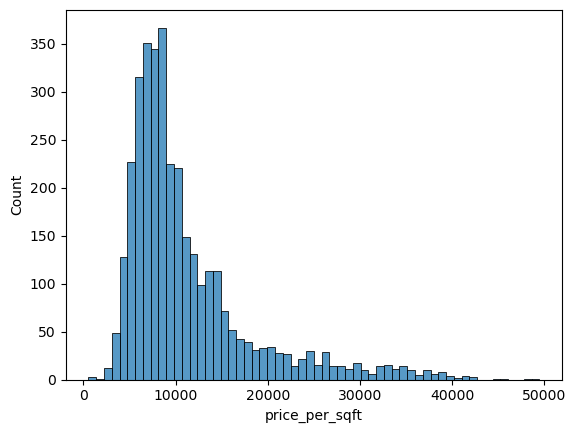

In [104]:
sns.histplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

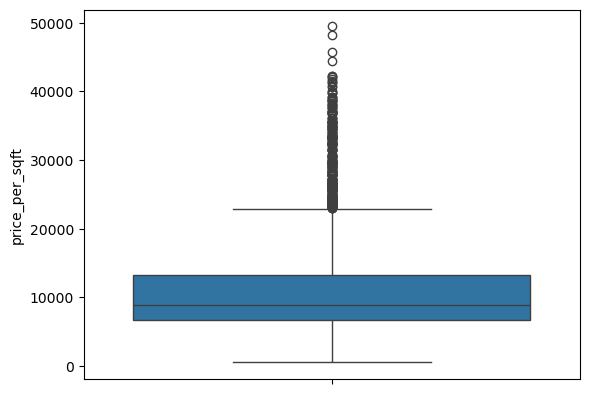

In [106]:
sns.boxplot(df['price_per_sqft'])

In [107]:
df[df['price_per_sqft'] > 30000]

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
59,5 Bedroom House for sale in DLF Phase 2,house,NaN,sector 25,4.35,32342.0,1345.00,Plot area 150(125.42 sq.m.),5,4,3,"DLF Phase 2, Gurgaon, Haryana",3.0,North,Old Property,Check out this 5 bhk house for sale in dlf pha...,NaN,150.0,NaN,0,1,0,0,0,1,49
72,5 Bedroom House for sale in DLF Phase 2,house,dlf city plots phase 2,sector 25,6.50,36173.0,1796.92,Plot area 200(167.23 sq.m.),5,5,3,"East Facing Duplex Villa, DLF Phase 2, Gurgaon...",3.0,East,Old Property,Not actual photos. Uploaded photos are for ref...,NaN,200.0,NaN,1,1,1,1,0,0,134
98,5 Bedroom House for sale in DLF Phase 3,house,NaN,sector 24,3.50,32528.0,1076.00,Plot area 120(100.34 sq.m.),5,4,3,"DLF Phase 3, Gurgaon, Haryana",3.0,North-West,Old Property,Interested to sell independent house/villa.Pla...,NaN,120.0,NaN,0,0,0,0,0,1,15
106,4 Bedroom House for sale in Nirvana Country,house,NaN,sector 50,10.45,38693.0,2700.76,Plot area 2700(250.84 sq.m.)Built Up area: 400...,4,5,2,"Espace Nirvana Country Gurgaon, Nirvana Countr...",3.0,North,Moderately Old,4 bhk park facing prime location villa in \nNi...,NaN,4000.0,NaN,1,1,0,1,0,0,142
130,9 Bedroom House for sale in DLF Phase 2,house,NaN,sector 25,7.30,37691.0,1936.80,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,"Dlf Phase 2, DLF Phase 2, Gurgaon, Haryana",3.0,North-West,Relatively New,"Floorwise builtup house with basement, stilt w...",NaN,5800.0,5200.0,0,1,1,0,0,0,109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3481,5 Bedroom House for sale in Sector 66 Gurgaon,house,emaar mgf marbella,sector 66,12.00,37051.0,3238.76,Plot area 360(301.01 sq.m.),5,5,3,"Sector 66 Gurgaon, Gurgaon, Haryana",3.0,East,New Property,Available for sale 5bhk independent house in e...,NaN,360.0,NaN,0,1,1,1,0,0,106
3516,4 Bedroom House for sale in DLF Phase 2,house,NaN,sector 25,6.50,36173.0,1796.92,Plot area 200(167.23 sq.m.),4,4,3,"Dlf Phase 2, Gurugram, DLF Phase 2, Gurgaon, H...",2.0,North-East,Moderately Old,200 sq yards build up house available for sale...,NaN,200.0,NaN,1,1,1,1,0,1,61
3523,4 Bedroom House for sale in Nirvana Country,house,unitech nirvana birch court,sector 50,6.80,31441.0,2162.76,Plot area 240(200.67 sq.m.),4,4,3,"Nirvana Country, Gurgaon, Haryana",2.0,South-East,Old Property,Available for villa in birch court nirvana cou...,NaN,240.0,NaN,1,1,0,1,0,1,105
3532,9 Bedroom House for sale in DLF Phase 2,house,NaN,sector 25,7.60,39240.0,1936.80,Plot area 215(179.77 sq.m.),9,9,3,"2/22, DLF Phase 2, Gurgaon, Haryana",4.0,East,Relatively New,Sale - Kothi in gurgaon\n# dlf phase -2 ()\n# ...,NaN,215.0,NaN,1,0,1,1,0,0,84


In [108]:
df.to_csv('data_uotlier_treated.csv', index=False)